# Analisis Morfometri Culex quinquefasciatus Say.
## PCA, Perbandingan Antar Lokasi, dan Dendogram

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import os
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

# Buat folder Results
RESULTS = 'Results'
os.makedirs(RESULTS, exist_ok=True)
print("Libraries loaded successfully!")
print(f"Output folder: {os.path.abspath(RESULTS)}")

Libraries loaded successfully!
Output folder: C:\Users\H P\Downloads\Biosishew Nyamuk\Results


In [2]:
df = pd.read_excel('MORFOMETRI ANALISIS-CULEX.xlsx', sheet_name='Data Mentah', header=4)
df.columns = ['No', 'Spesimen', 'Locality', 'Proboscis', 'Thoraks', 'Abdomen', 'Sayap', 'Kaki_Depan', 'Kaki_Tengah', 'Kaki_Belakang']
df = df.dropna(subset=['No'])
features = ['Proboscis', 'Thoraks', 'Abdomen', 'Sayap', 'Kaki_Depan', 'Kaki_Tengah', 'Kaki_Belakang']
print(f"Total spesimen: {len(df)}")
print(f"\nJumlah per lokasi:")
print(df['Locality'].value_counts())
print(f"\nStatistik deskriptif:")
df[features].describe().round(2)

Total spesimen: 74

Jumlah per lokasi:
Locality
Kabupaten II          21
Semarang Kota         21
Kabupaten I           20
Semarang Kabupaten    12
Name: count, dtype: int64

Statistik deskriptif:


,Proboscis,Thoraks,Abdomen,Sayap,Kaki_Depan,Kaki_Tengah,Kaki_Belakang
count,74.00,74.00,74.00,74.00,74.00,74.00,74.00
mean,1.84,1.41,2.98,3.43,6.14,7.15,9.02
std,0.39,0.28,0.60,0.73,1.20,1.43,1.65
min,1.13,0.79,1.93,1.97,3.02,3.21,5.46
25%,1.63,1.25,2.62,3.03,5.44,6.42,8.02
50%,1.79,1.34,2.90,3.28,6.02,7.02,8.85
75%,2.05,1.54,3.15,3.69,6.77,7.93,9.76
max,2.96,2.29,4.89,5.25,9.40,10.98,13.31


## 1. Principal Component Analysis (PCA)
PCA digunakan untuk mereduksi dimensi data morfometri dan memvisualisasikan pola pengelompokan spesimen berdasarkan lokasi.

In [3]:
# Standardisasi data
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
pca_scores = pca.fit_transform(X_scaled)

# Variance explained
print("Explained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"\nTotal variance (PC1+PC2): {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")

# Loadings
loadings = pd.DataFrame(pca.components_[:2].T, columns=['PC1','PC2'], index=features)
print("\nPCA Loadings:")
print(loadings.round(4))

Explained Variance Ratio:
  PC1: 0.7420 (74.20%)
  PC2: 0.0792 (7.92%)
  PC3: 0.0501 (5.01%)
  PC4: 0.0446 (4.46%)
  PC5: 0.0332 (3.32%)
  PC6: 0.0301 (3.01%)
  PC7: 0.0209 (2.09%)

Total variance (PC1+PC2): 82.12%

PCA Loadings:
                  PC1     PC2
Proboscis      0.3780 -0.4223
Thoraks        0.3913 -0.2445
Abdomen        0.3725 -0.2993
Sayap          0.3888 -0.2130
Kaki_Depan     0.3730  0.4333
Kaki_Tengah    0.3477  0.6417
Kaki_Belakang  0.3927  0.1654


### Scree Plot - Variance Explained

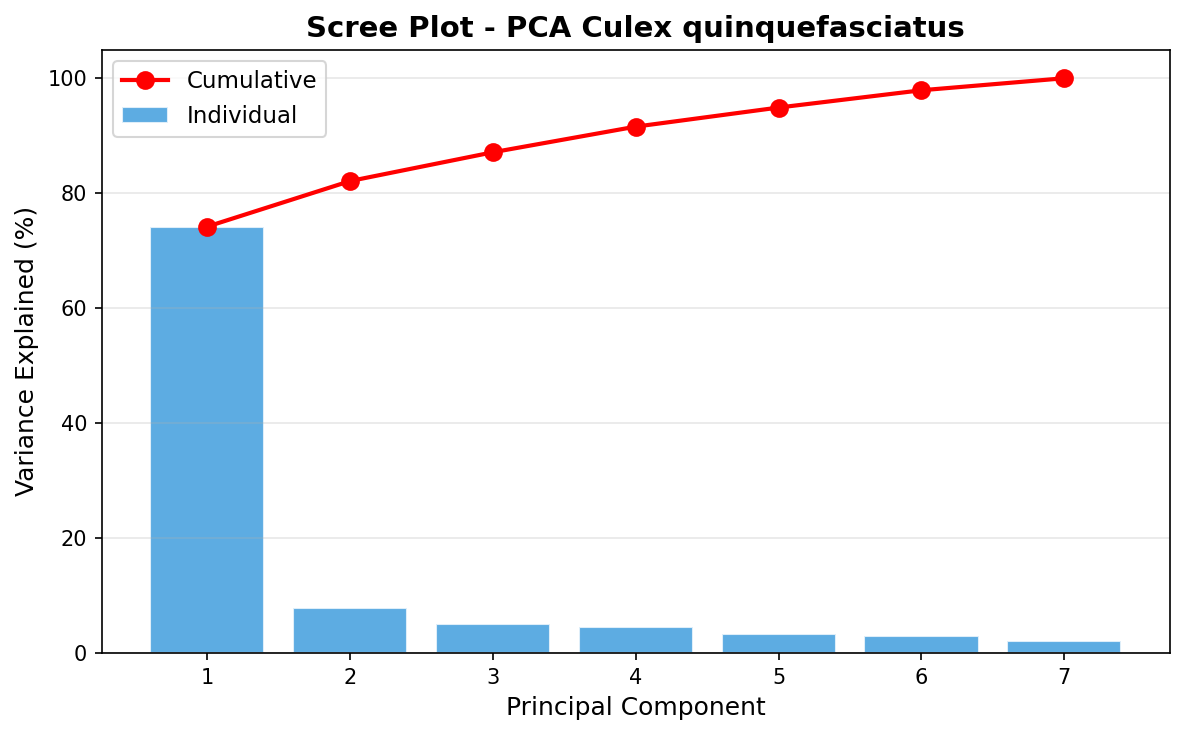

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
pcs = range(1, len(pca.explained_variance_ratio_)+1)
ax.bar(pcs, pca.explained_variance_ratio_*100, color='#3498db', edgecolor='white', alpha=0.8)
ax.plot(pcs, np.cumsum(pca.explained_variance_ratio_)*100, 'ro-', markersize=8, linewidth=2)
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Variance Explained (%)', fontsize=12)
ax.set_title('Scree Plot - PCA Culex quinquefasciatus', fontsize=14, fontweight='bold')
ax.set_xticks(list(pcs))
ax.legend(['Cumulative', 'Individual'], fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'Scree_Plot_Culex.png'), dpi=300, bbox_inches='tight')
plt.show()

### PCA Scatter Plot

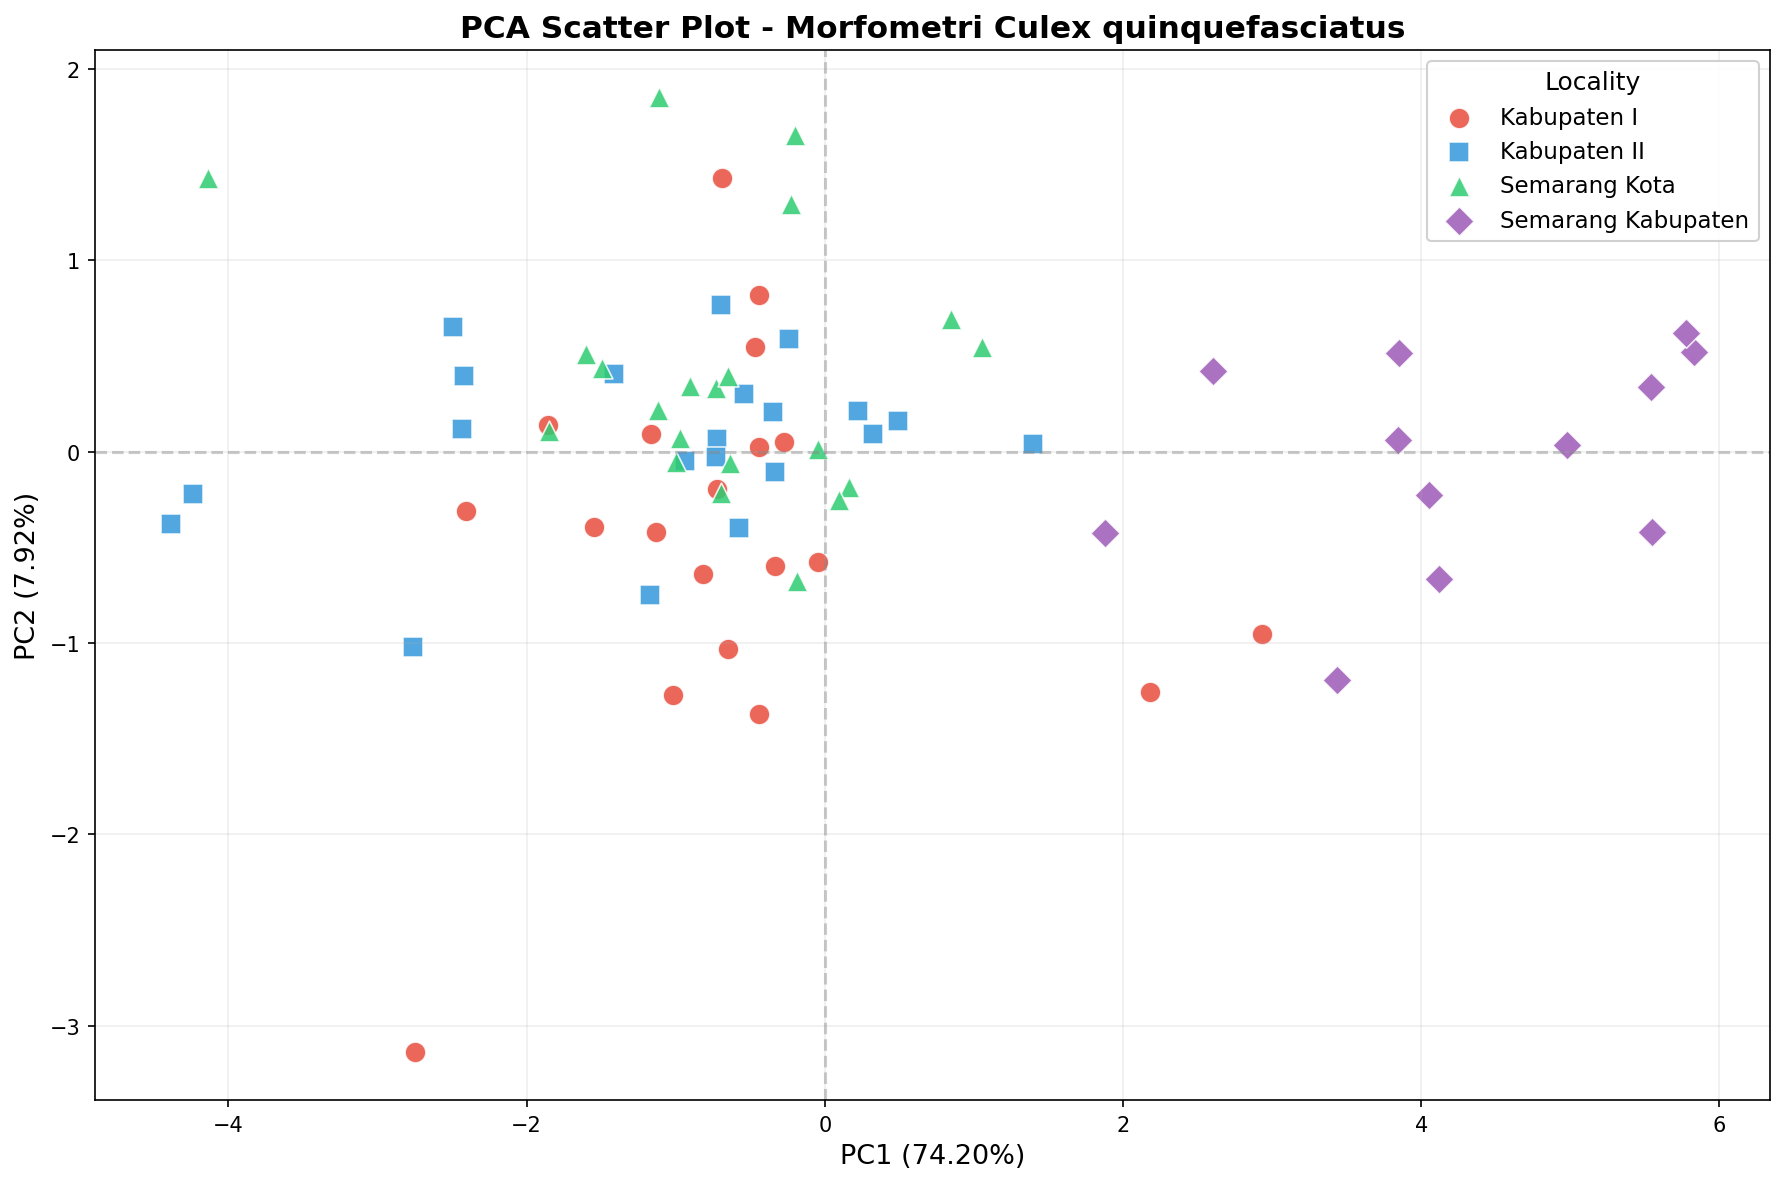

Saved: Results/PCA_Scatter_Culex.png


In [5]:
colors = {'Kabupaten I':'#e74c3c', 'Kabupaten II':'#3498db', 'Semarang Kota':'#2ecc71', 'Semarang Kabupaten':'#9b59b6'}
markers = {'Kabupaten I':'o', 'Kabupaten II':'s', 'Semarang Kota':'^', 'Semarang Kabupaten':'D'}

fig, ax = plt.subplots(figsize=(12, 8))
for loc in colors:
    mask = df['Locality'] == loc
    ax.scatter(pca_scores[mask, 0], pca_scores[mask, 1],
               c=colors[loc], marker=markers[loc], s=100, label=loc,
               edgecolors='white', linewidth=0.8, alpha=0.85)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=13)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=13)
ax.set_title('PCA Scatter Plot - Morfometri Culex quinquefasciatus', fontsize=15, fontweight='bold')
ax.legend(title='Locality', fontsize=11, title_fontsize=12, framealpha=0.9)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.4)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'PCA_Scatter_Culex.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: Results/PCA_Scatter_Culex.png")

### PCA Biplot
Biplot menampilkan skor PCA dan loading variabel secara bersamaan.

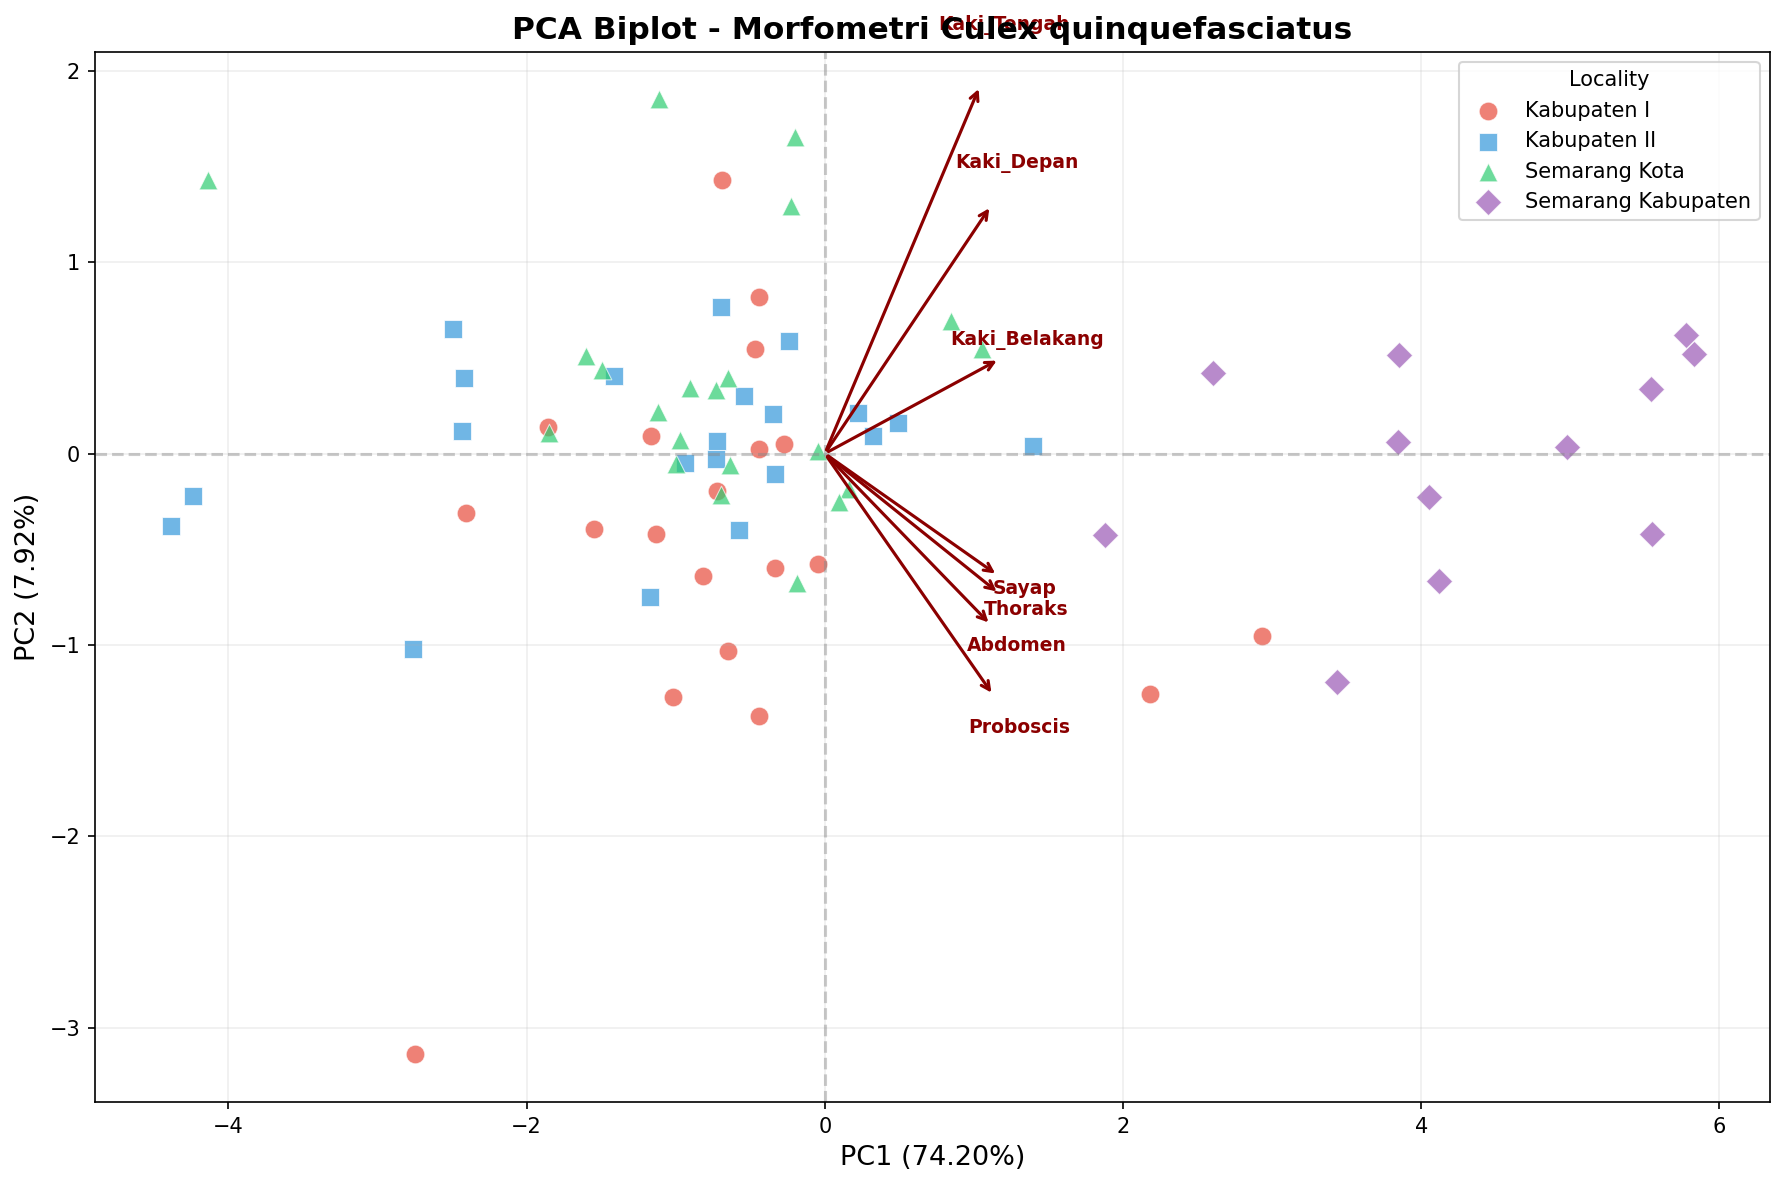

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))
for loc in colors:
    mask = df['Locality'] == loc
    ax.scatter(pca_scores[mask, 0], pca_scores[mask, 1],
               c=colors[loc], marker=markers[loc], s=80, label=loc,
               edgecolors='white', linewidth=0.5, alpha=0.7)

# Loading arrows
scale = 3
for i, feat in enumerate(features):
    ax.annotate('', xy=(pca.components_[0,i]*scale, pca.components_[1,i]*scale),
                xytext=(0,0), arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))
    ax.text(pca.components_[0,i]*scale*1.15, pca.components_[1,i]*scale*1.15,
            feat, fontsize=9, fontweight='bold', color='darkred', ha='center')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=13)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=13)
ax.set_title('PCA Biplot - Morfometri Culex quinquefasciatus', fontsize=15, fontweight='bold')
ax.legend(title='Locality', fontsize=10)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.4)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'PCA_Biplot_Culex.png'), dpi=300, bbox_inches='tight')
plt.show()

## 2. Perbandingan Antar Lokasi
### Box Plot untuk setiap parameter morfometri

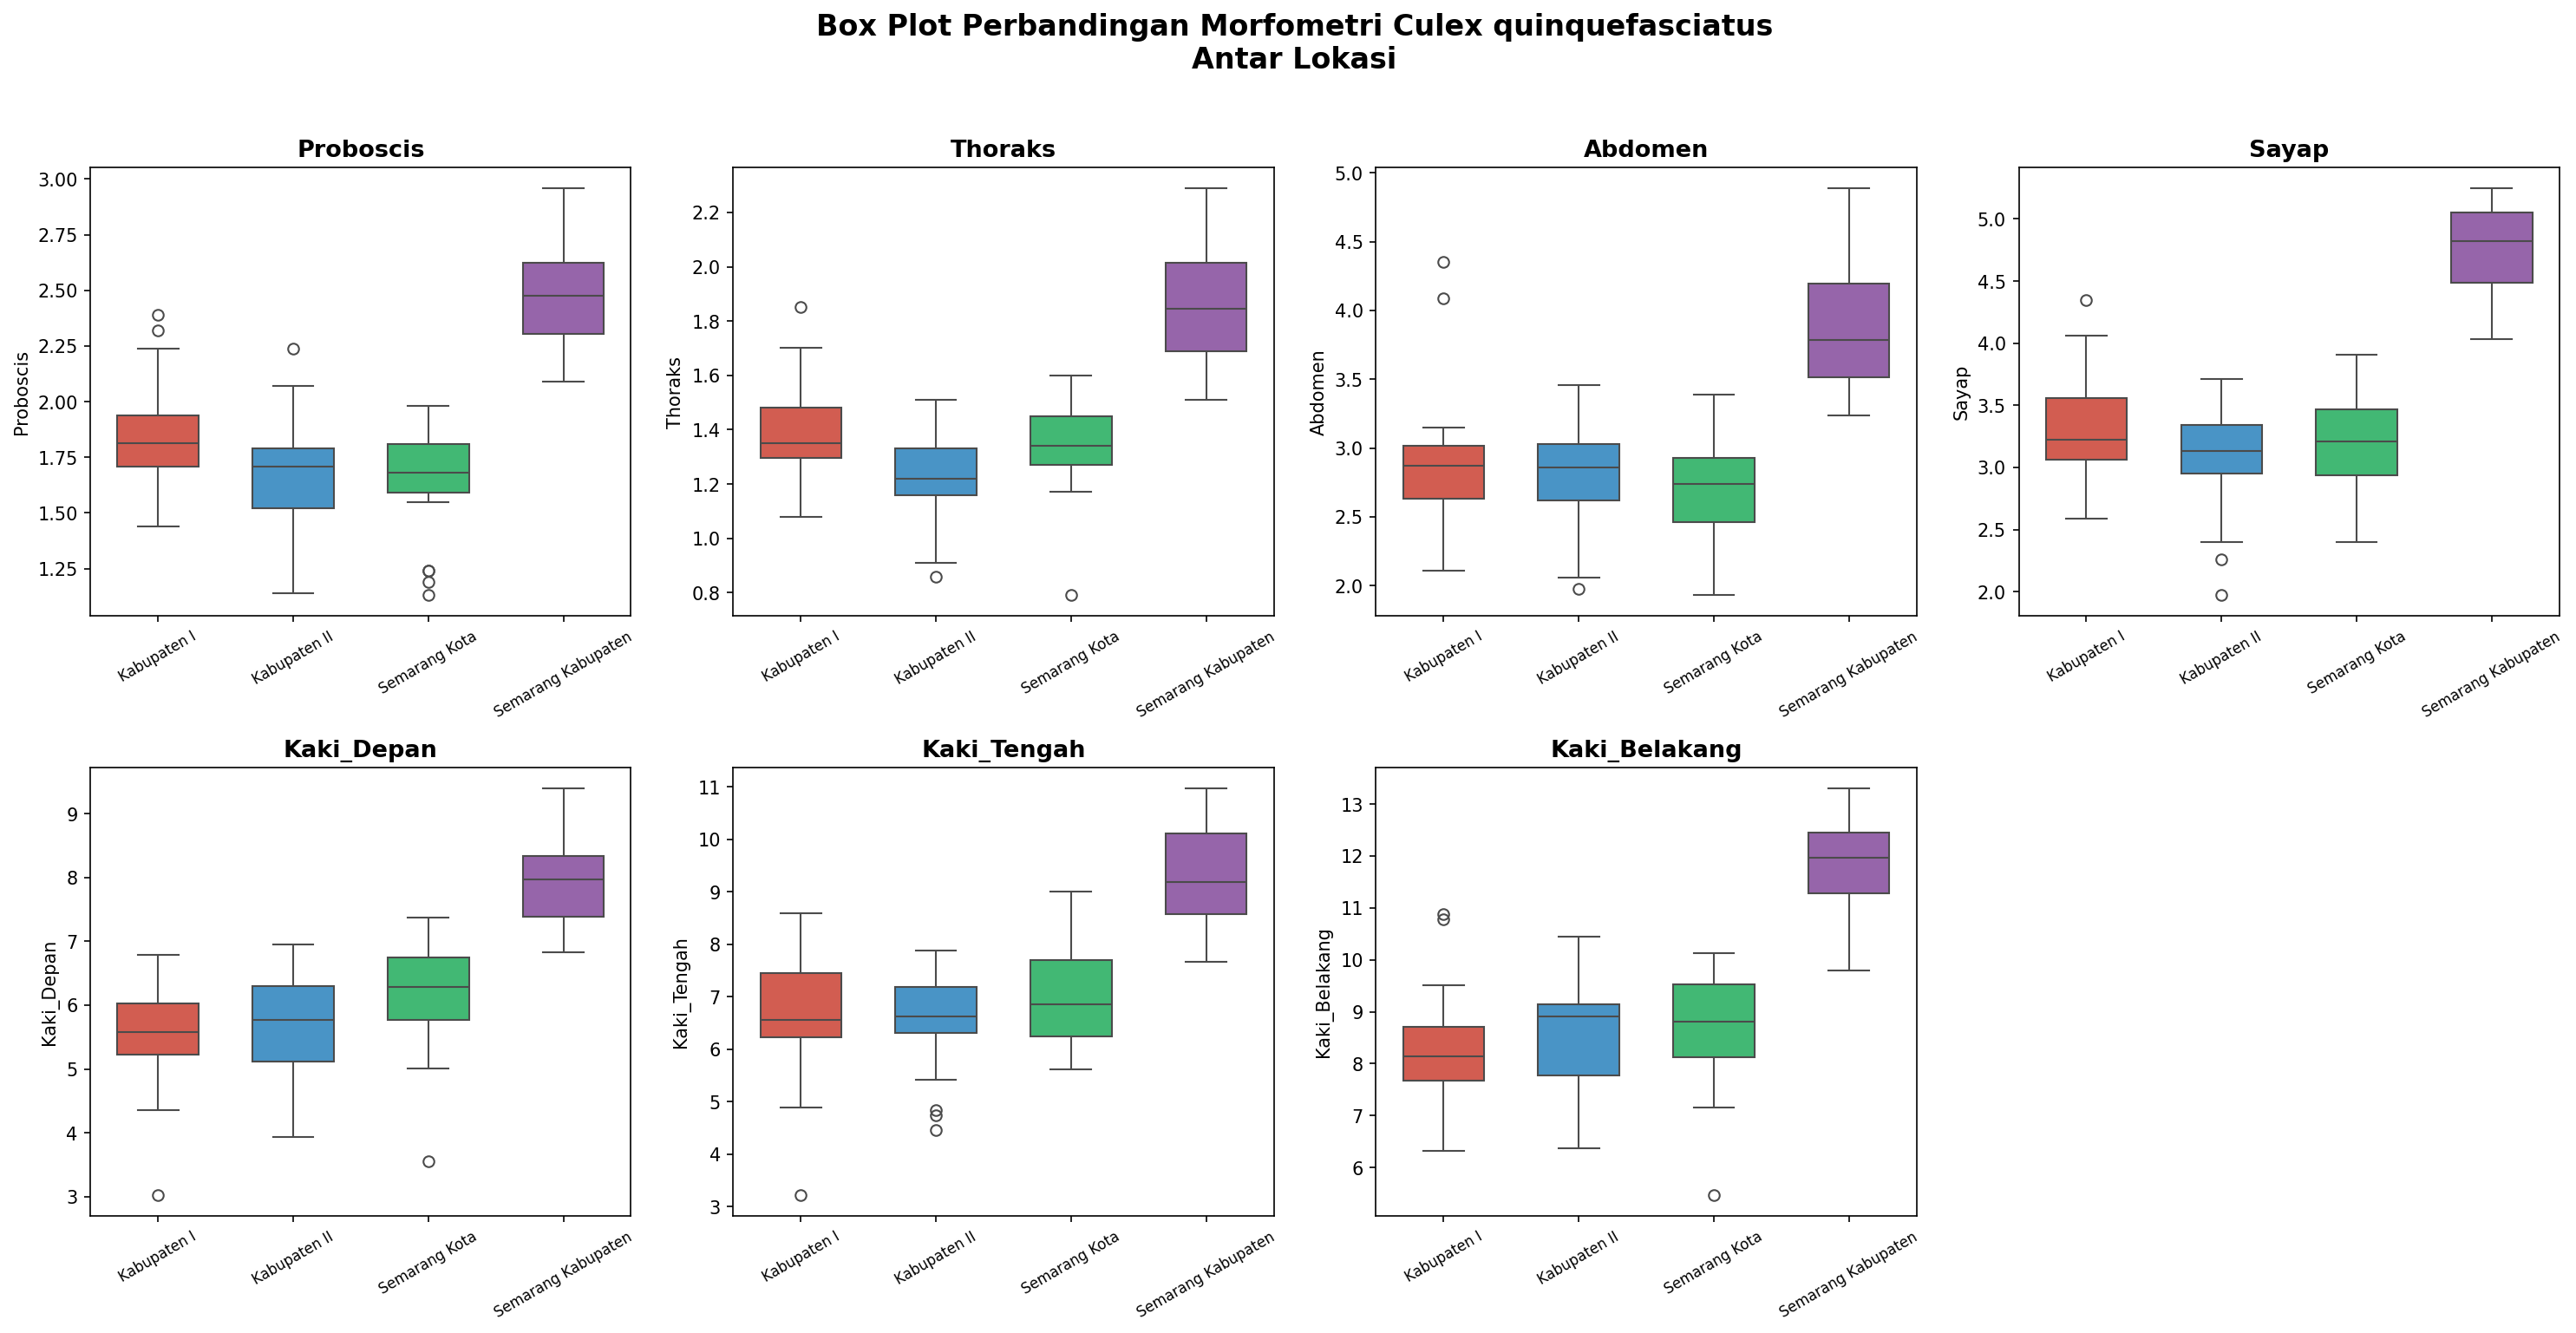

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
order = ['Kabupaten I', 'Kabupaten II', 'Semarang Kota', 'Semarang Kabupaten']
palette = [colors[k] for k in order]

for i, feat in enumerate(features):
    sns.boxplot(data=df, x='Locality', y=feat, order=order, palette=palette, ax=axes[i], width=0.6)
    axes[i].set_title(feat, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

axes[-1].axis('off')
fig.suptitle('Box Plot Perbandingan Morfometri Culex quinquefasciatus\nAntar Lokasi', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'Boxplot_Comparison_Culex.png'), dpi=300, bbox_inches='tight')
plt.show()

### Violin Plot - Distribusi Data per Lokasi

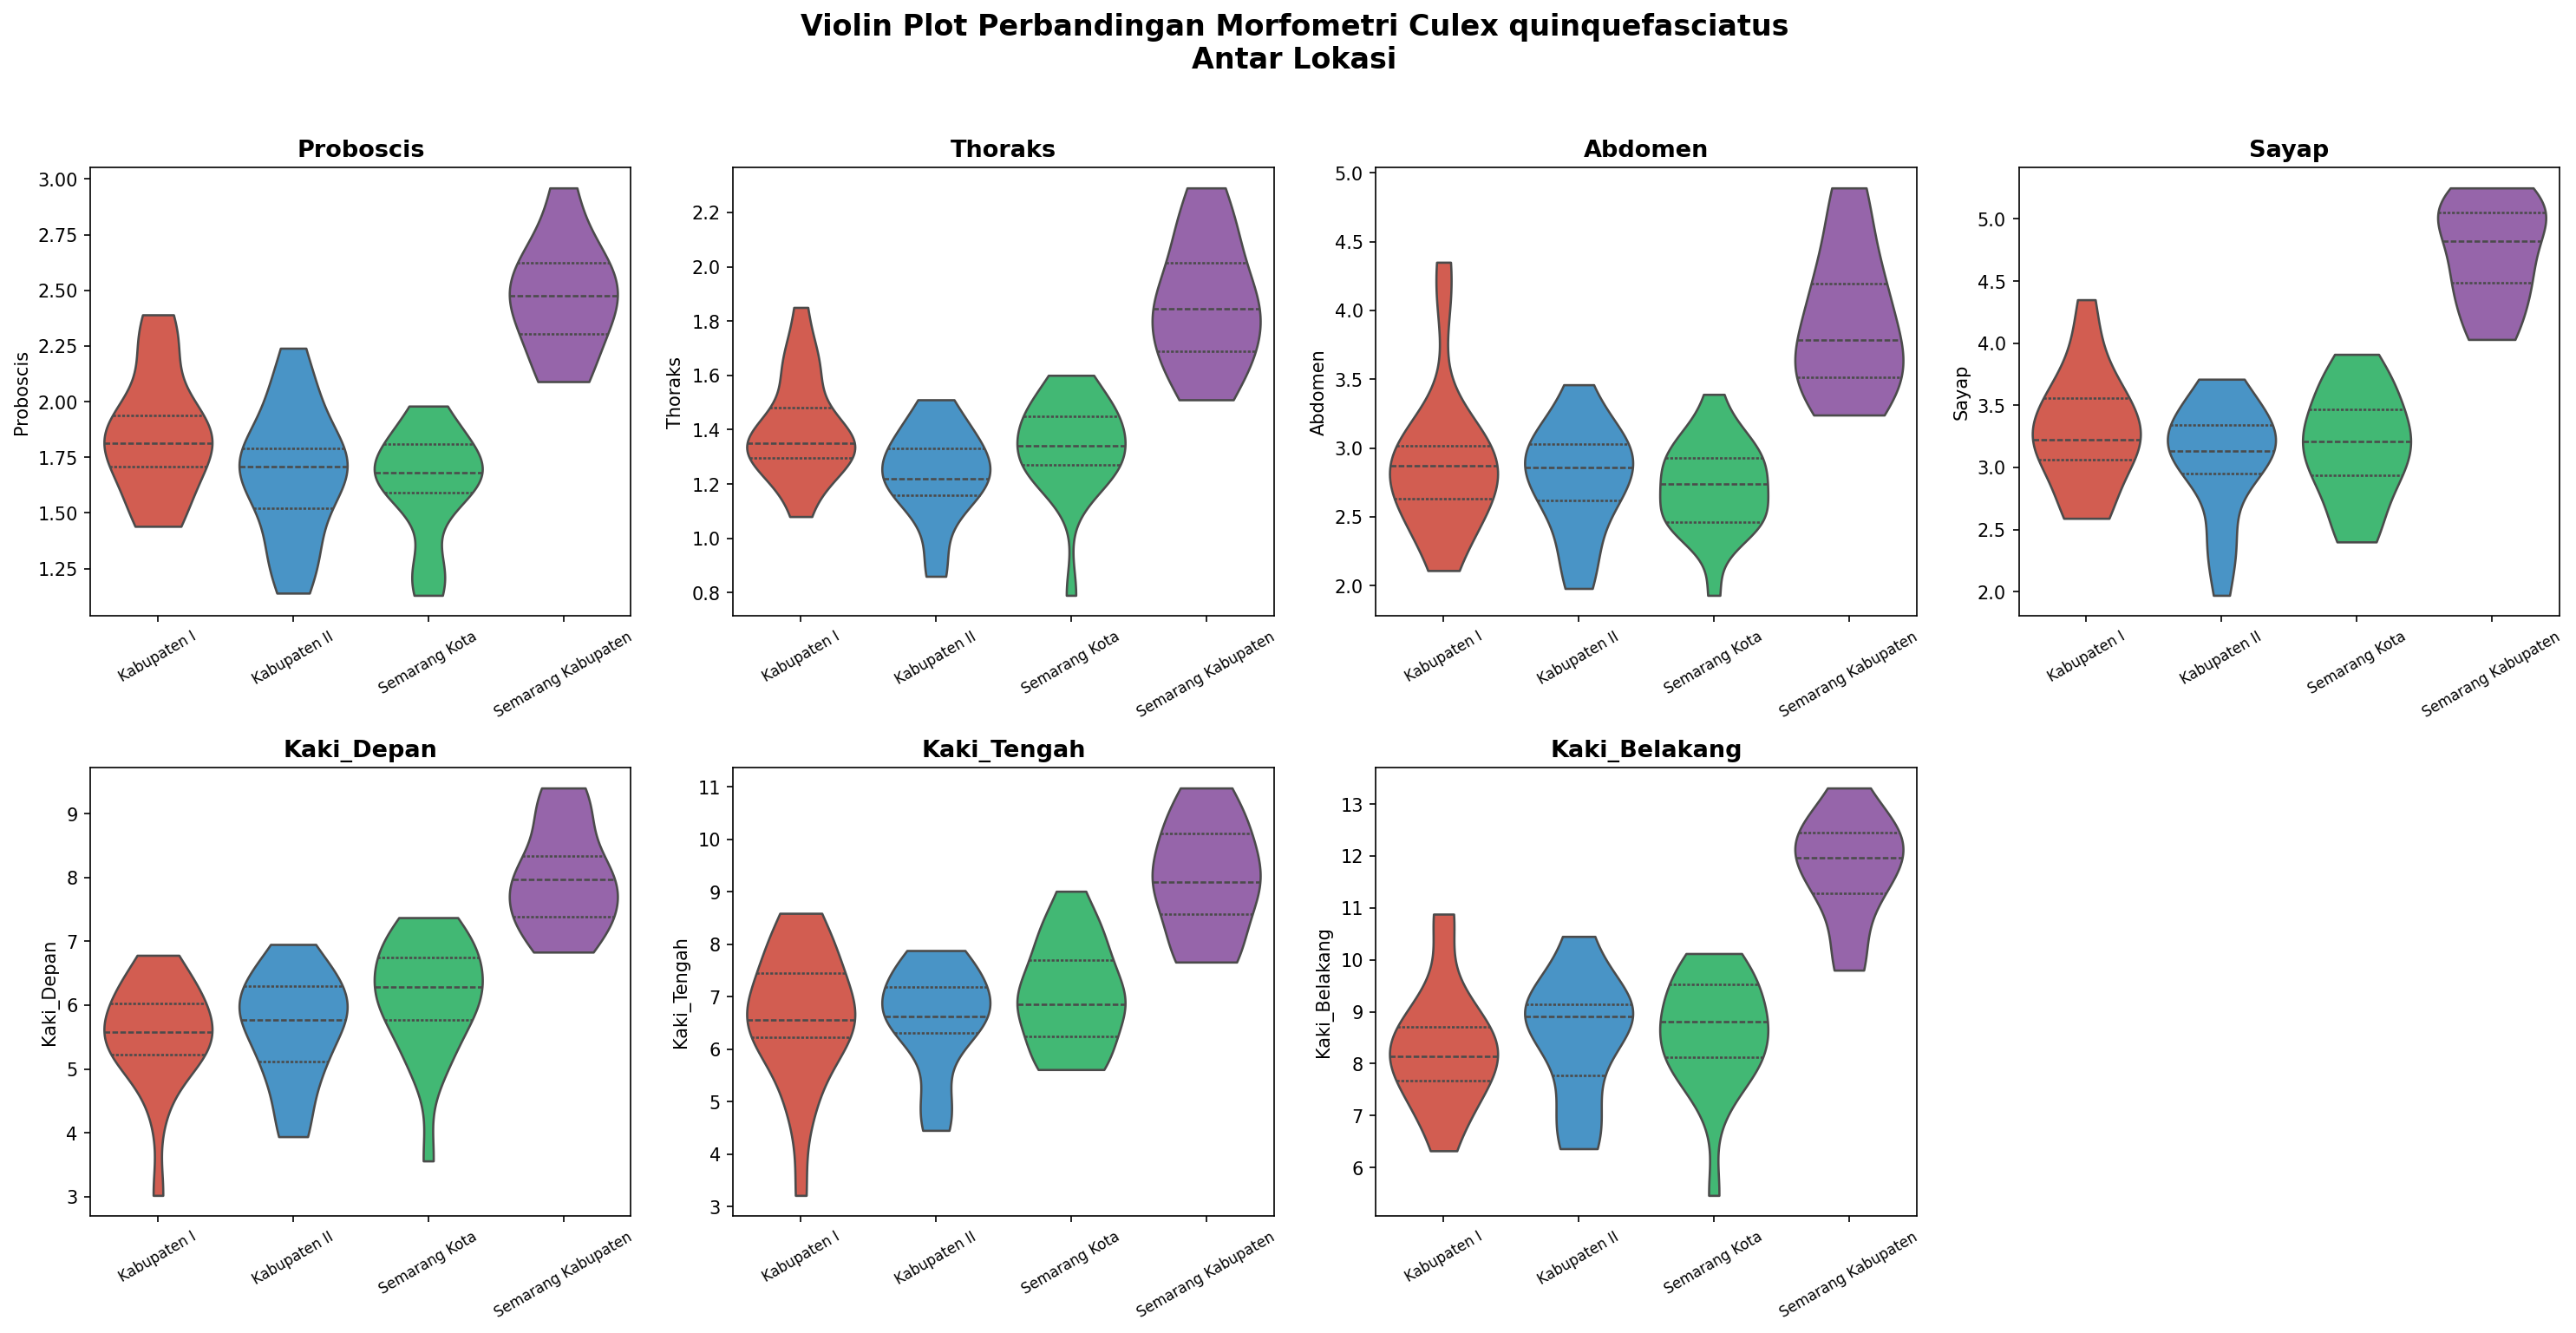

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.violinplot(data=df, x='Locality', y=feat, order=order, palette=palette,
                   ax=axes[i], inner='quartile', cut=0)
    axes[i].set_title(feat, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

axes[-1].axis('off')
fig.suptitle('Violin Plot Perbandingan Morfometri Culex quinquefasciatus\nAntar Lokasi', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'Violin_Comparison_Culex.png'), dpi=300, bbox_inches='tight')
plt.show()

### Heatmap Rata-rata Morfometri per Lokasi

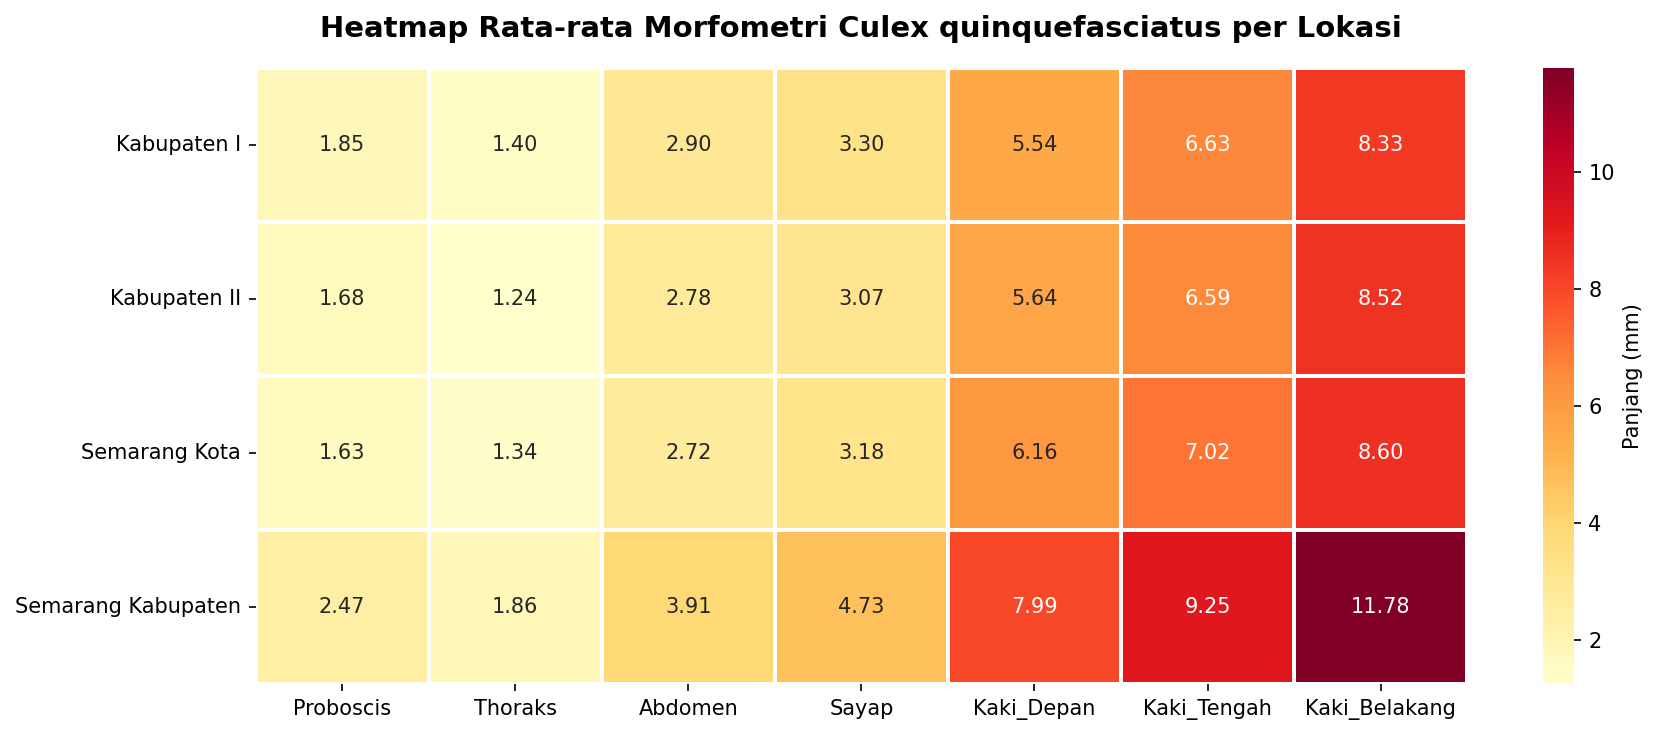


Tabel Rata-rata:
                    Proboscis  Thoraks  Abdomen  Sayap  Kaki_Depan  \
Locality                                                             
Kabupaten I             1.855    1.404    2.896  3.302       5.545   
Kabupaten II            1.680    1.238    2.775  3.072       5.642   
Semarang Kota           1.627    1.345    2.718  3.180       6.160   
Semarang Kabupaten      2.470    1.864    3.914  4.734       7.987   

                    Kaki_Tengah  Kaki_Belakang  
Locality                                        
Kabupaten I               6.627          8.326  
Kabupaten II              6.586          8.519  
Semarang Kota             7.019          8.597  
Semarang Kabupaten        9.250         11.780  


In [9]:
mean_df = df.groupby('Locality')[features].mean().reindex(order)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(mean_df, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=1,
            linecolor='white', ax=ax, cbar_kws={'label': 'Panjang (mm)'})
ax.set_title('Heatmap Rata-rata Morfometri Culex quinquefasciatus per Lokasi',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'Heatmap_Mean_Culex.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\nTabel Rata-rata:")
print(mean_df.round(3))

### Bar Chart Perbandingan Rata-rata ± SD

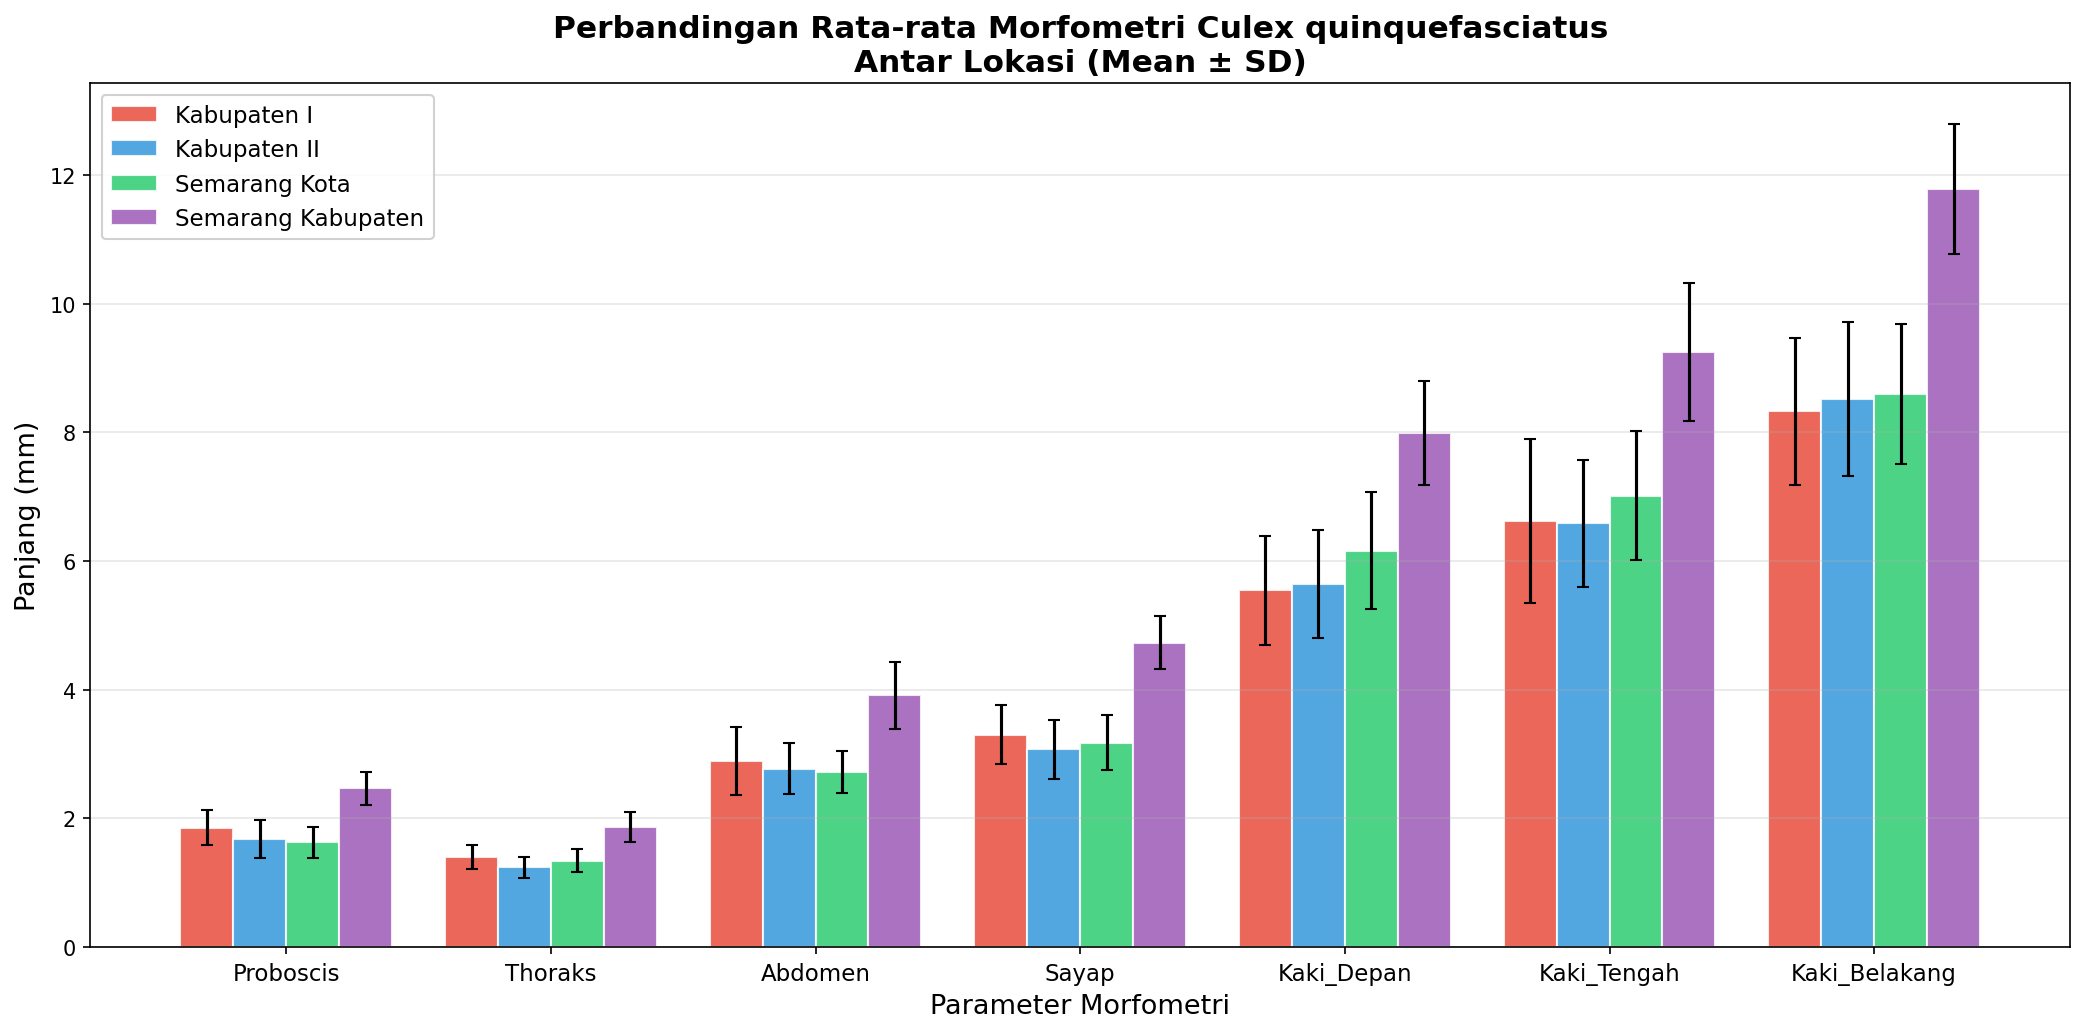

In [10]:
mean_vals = df.groupby('Locality')[features].mean().reindex(order)
std_vals = df.groupby('Locality')[features].std().reindex(order)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(features))
width = 0.2

for i, loc in enumerate(order):
    ax.bar(x + i*width, mean_vals.loc[loc], width, yerr=std_vals.loc[loc],
           label=loc, color=colors[loc], edgecolor='white', capsize=3, alpha=0.85)

ax.set_xlabel('Parameter Morfometri', fontsize=13)
ax.set_ylabel('Panjang (mm)', fontsize=13)
ax.set_title('Perbandingan Rata-rata Morfometri Culex quinquefasciatus\nAntar Lokasi (Mean ± SD)',
             fontsize=15, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(features, fontsize=11)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'BarChart_Comparison_Culex.png'), dpi=300, bbox_inches='tight')
plt.show()

### Radar Chart - Profil Morfometri per Lokasi

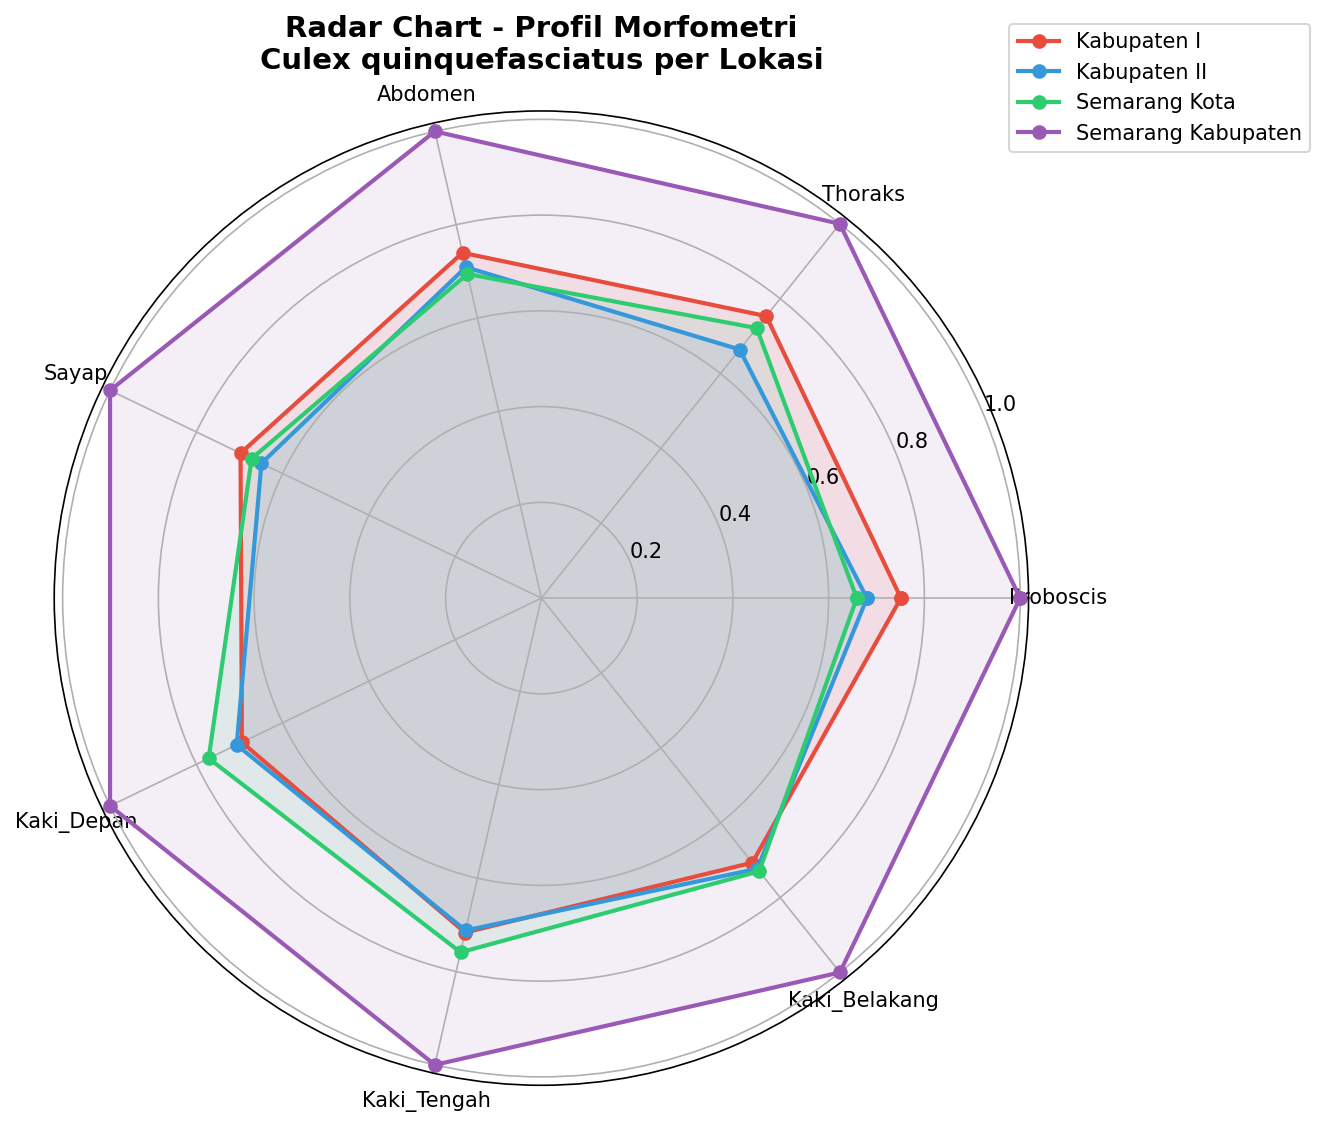

In [11]:
from math import pi

mean_norm = mean_vals.copy()
for col in features:
    mean_norm[col] = mean_vals[col] / mean_vals[col].max()

angles = [n / float(len(features)) * 2 * pi for n in range(len(features))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for loc in order:
    vals = mean_norm.loc[loc].values.tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=loc, color=colors[loc], markersize=6)
    ax.fill(angles, vals, alpha=0.1, color=colors[loc])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=10)
ax.set_title('Radar Chart - Profil Morfometri\nCulex quinquefasciatus per Lokasi',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'Radar_Comparison_Culex.png'), dpi=300, bbox_inches='tight')
plt.show()

## 3. Dendogram Culex quinquefasciatus
Analisis klaster hierarki menggunakan metode Ward untuk mengelompokkan spesimen berdasarkan kesamaan morfometri.

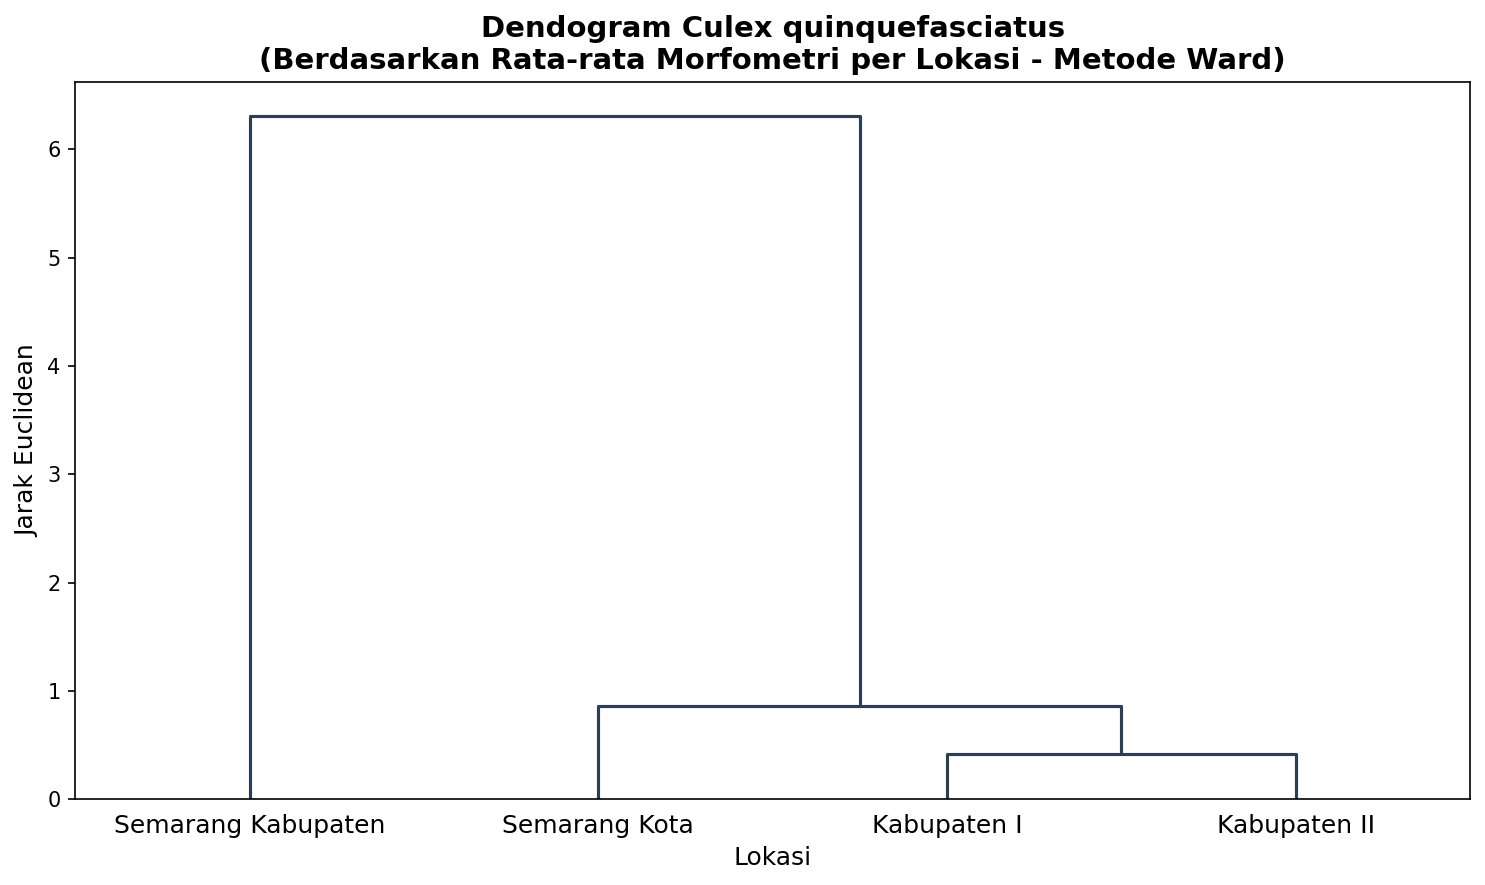

In [12]:
# Dendrogram berdasarkan rata-rata per lokasi
mean_data = df.groupby('Locality')[features].mean().reindex(order)
Z_loc = linkage(mean_data, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(10, 6))
dn = dendrogram(Z_loc, labels=order, ax=ax, leaf_font_size=12,
                color_threshold=0, above_threshold_color='#2c3e50')
ax.set_title('Dendogram Culex quinquefasciatus\n(Berdasarkan Rata-rata Morfometri per Lokasi - Metode Ward)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Jarak Euclidean', fontsize=12)
ax.set_xlabel('Lokasi', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'Dendrogram_Locality_Culex.png'), dpi=300, bbox_inches='tight')
plt.show()

### Dendogram Semua Spesimen

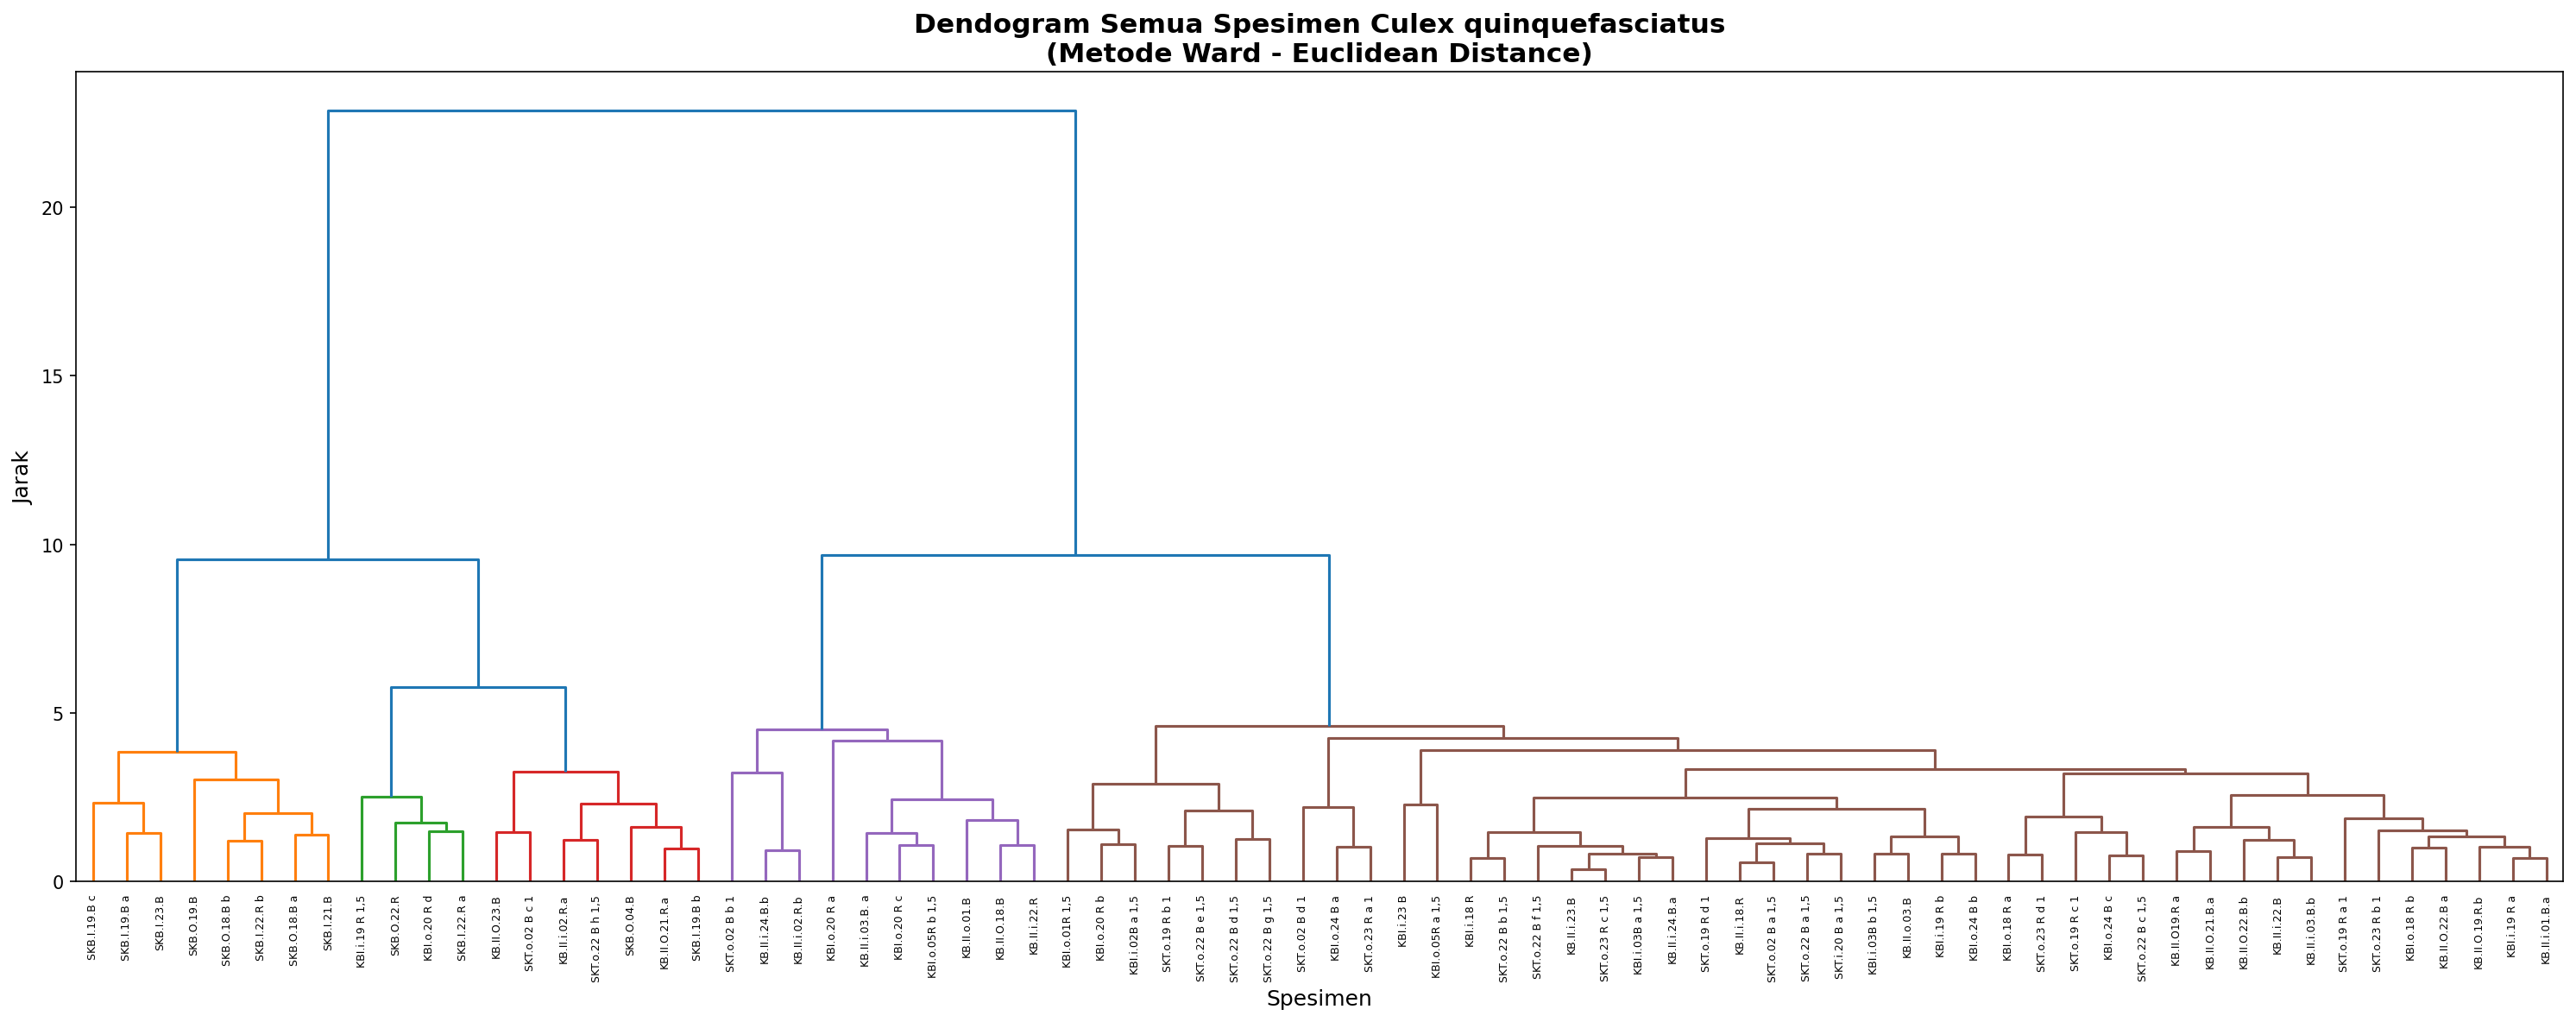

In [13]:
Z_all = linkage(X_scaled, method='ward', metric='euclidean')
label_list = [f"{row['Spesimen']}" for _, row in df.iterrows()]

fig, ax = plt.subplots(figsize=(20, 8))
dn = dendrogram(Z_all, labels=label_list, ax=ax, leaf_font_size=6,
                leaf_rotation=90, color_threshold=5)
ax.set_title('Dendogram Semua Spesimen Culex quinquefasciatus\n(Metode Ward - Euclidean Distance)',
             fontsize=15, fontweight='bold')
ax.set_ylabel('Jarak', fontsize=12)
ax.set_xlabel('Spesimen', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'Dendrogram_AllSpecimens_Culex.png'), dpi=300, bbox_inches='tight')
plt.show()

### Dendogram dengan Heatmap (Clustermap)

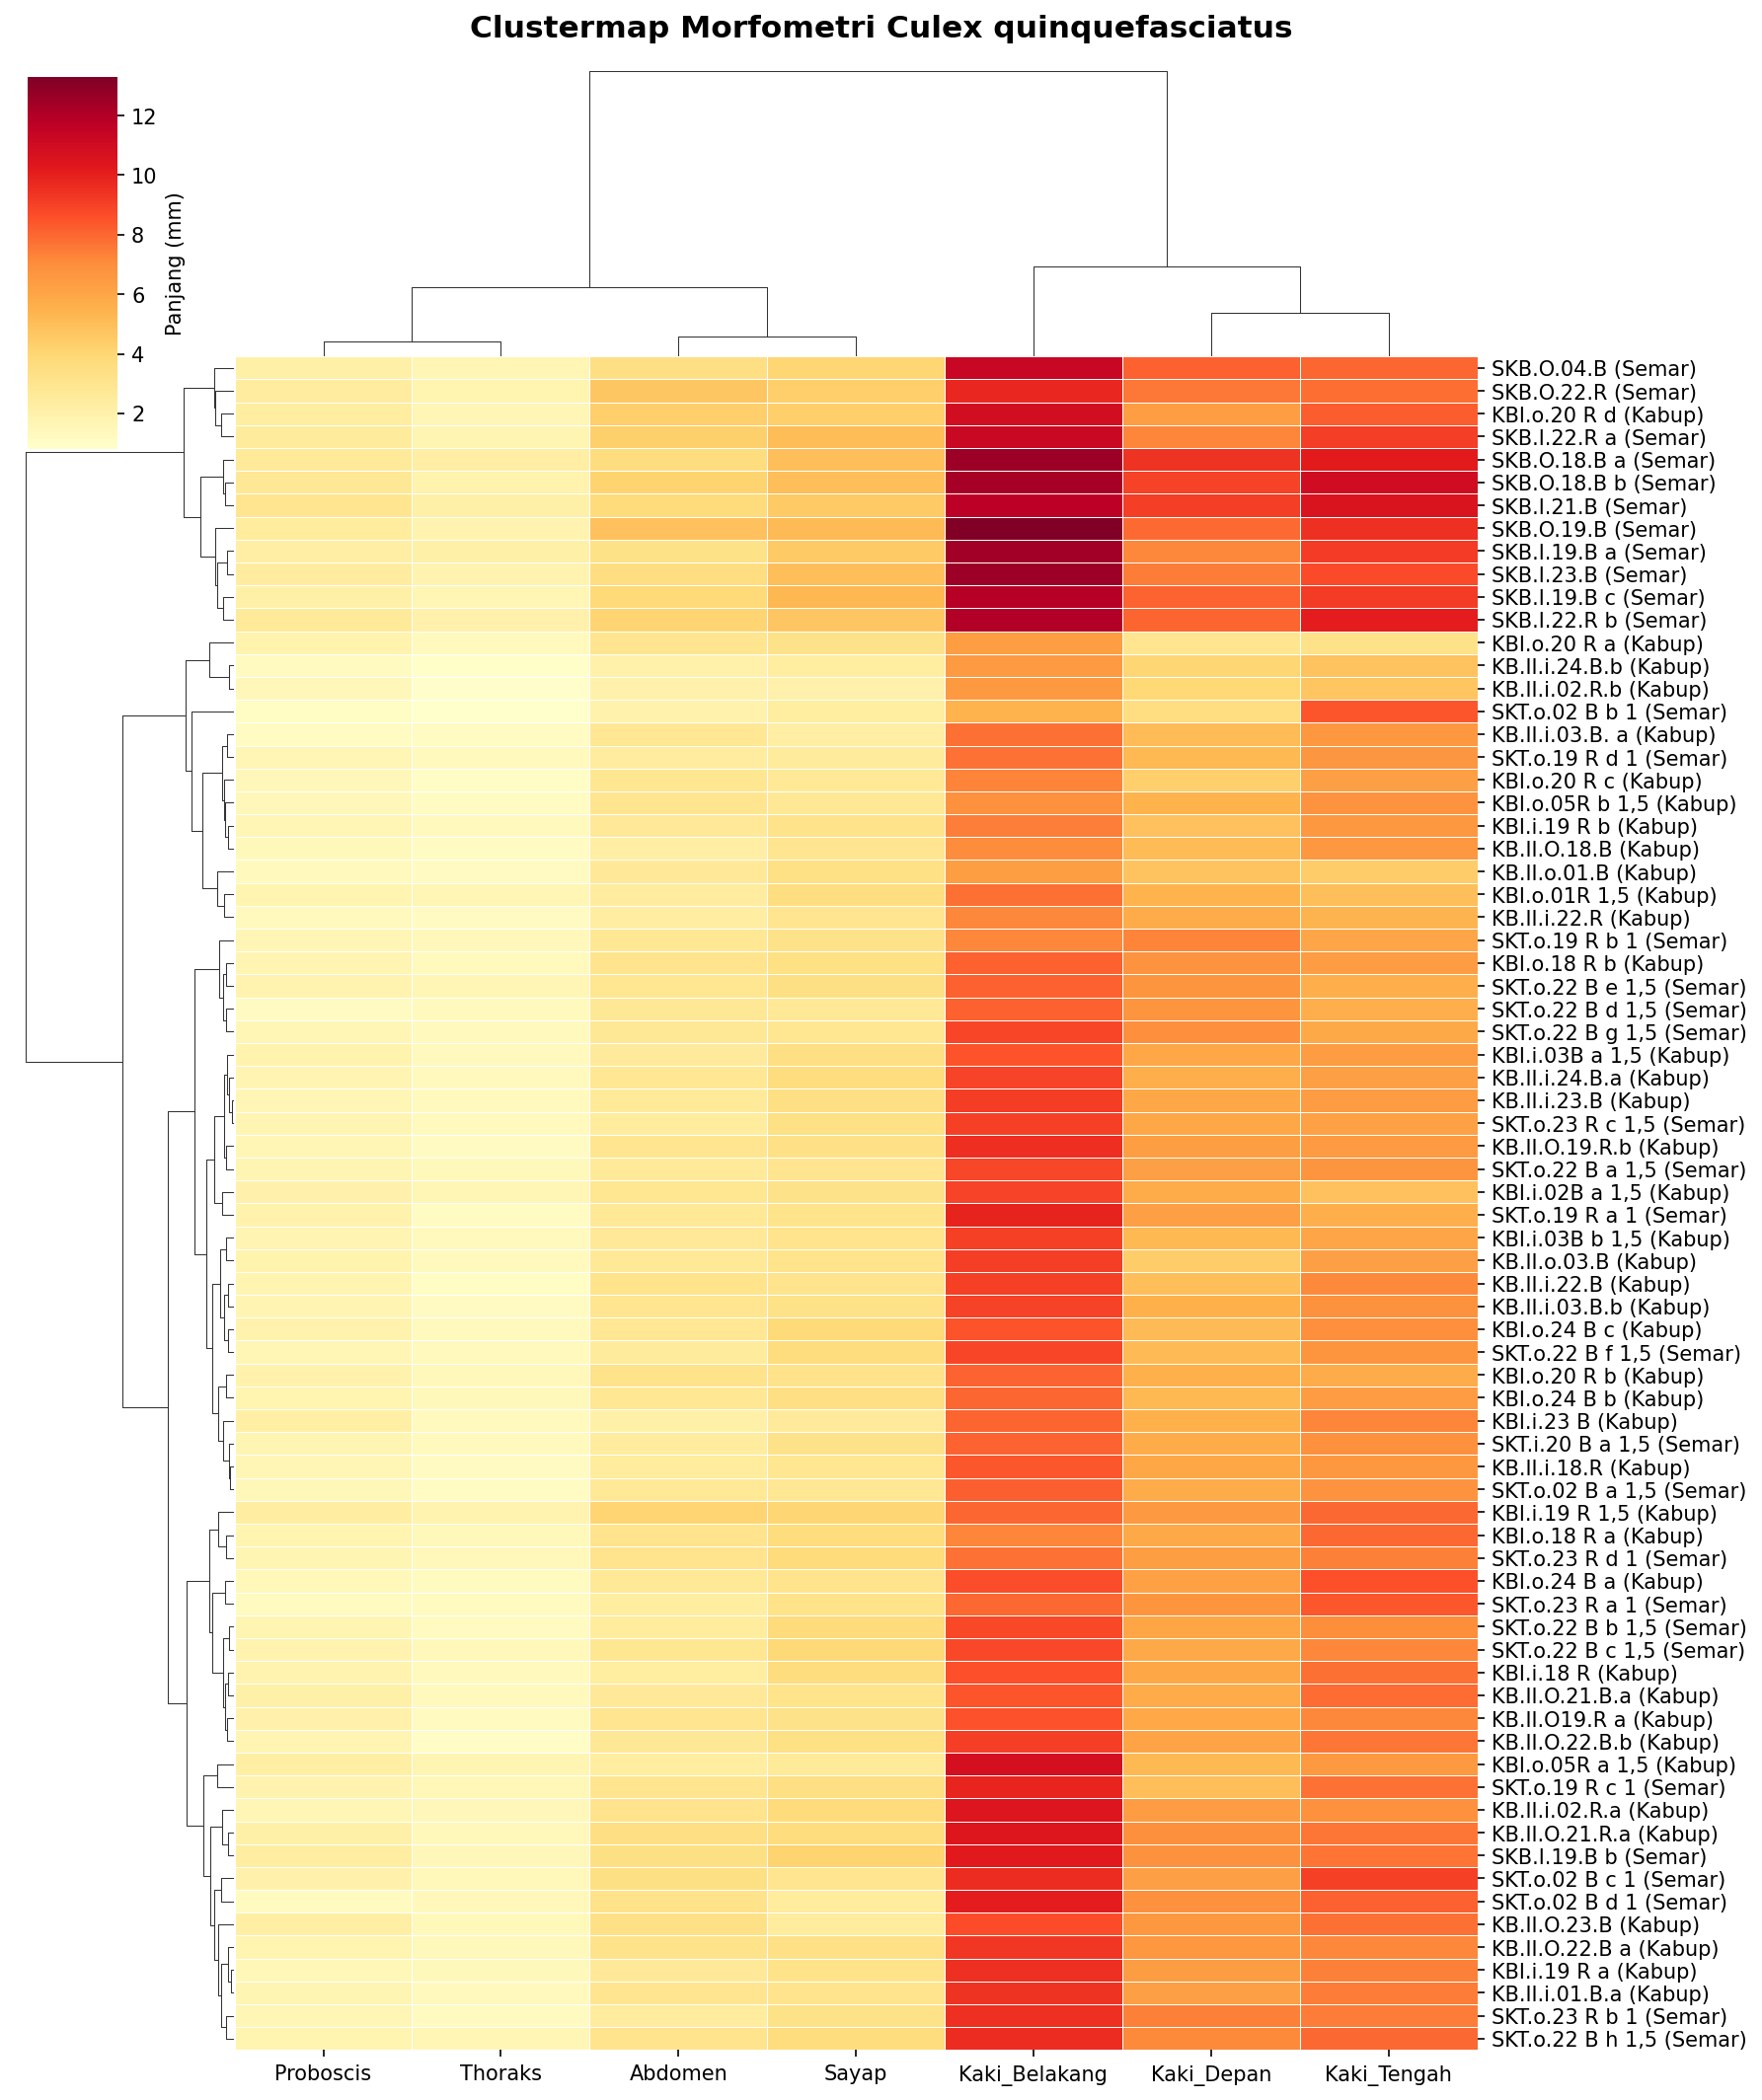

In [14]:
g = sns.clustermap(df[features].values, method='ward', metric='euclidean',
                   cmap='YlOrRd', figsize=(12, 14),
                   yticklabels=[f"{r['Spesimen']} ({r['Locality'][:5]})" for _,r in df.iterrows()],
                   xticklabels=features, linewidths=0.3,
                   dendrogram_ratio=(0.15, 0.15),
                   cbar_kws={'label': 'Panjang (mm)'})
g.fig.suptitle('Clustermap Morfometri Culex quinquefasciatus', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(os.path.join(RESULTS, 'Clustermap_Culex.png'), dpi=300, bbox_inches='tight')
plt.show()

## 4. Ringkasan Analisis
- **PCA**: Komponen utama PC1 dan PC2 menjelaskan variasi terbesar dalam data morfometri
- **Perbandingan**: Box plot, violin plot, heatmap, bar chart, dan radar chart menunjukkan perbedaan morfometri antar lokasi
- **Dendogram**: Analisis klaster hierarki (metode Ward) menunjukkan pengelompokan spesimen berdasarkan kesamaan morfometri